In [ ]:
import numpy as np       
import matplotlib.pyplot as plt  
import seaborn as sns          
sns.set_theme() 

In [3]:
np.random.seed(42)   # so we get same random numbers every run
X = np.linspace(0, 2*np.pi, 30)  # 30 x-values from 0 to 6.28
y = np.sin(X)                   # true sine wave values
noise = np.random.normal(0, 0.4, 30)  # 30 random noisy values
y = y + noise                   # add noise to the true values

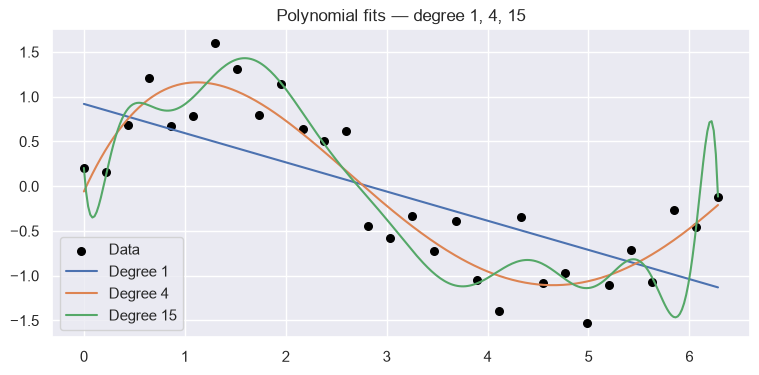

In [7]:
X_smooth = np.linspace(0, 2 * np.pi, 300)  # smooth line for drawing

c1  = np.polyfit(X_train, y_train, 1)   # fit degree 1
c4  = np.polyfit(X_train, y_train, 4)   # fit degree 4
c15 = np.polyfit(X_train, y_train, 15)  # fit degree 15

plt.figure(figsize=(9, 4))
plt.scatter(X, y, color='black', s=30, label='Data')    # plot data dots
plt.plot(X_smooth, np.polyval(c1,  X_smooth), label='Degree 1')
plt.plot(X_smooth, np.polyval(c4,  X_smooth), label='Degree 4')
plt.plot(X_smooth, np.polyval(c15, X_smooth).clip(-3, 3), label='Degree 15')
plt.legend()
plt.title('Polynomial fits — degree 1, 4, 15')
plt.show()

In [5]:
train_errors = []
val_errors   = []
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]

for deg in degrees:
    c = np.polyfit(X_train, y_train, deg)       # train on training data

    pred_train = np.polyval(c, X_train)          # predict on training
    pred_val   = np.polyval(c, X_val)            # predict on validation

    mse_train = np.mean((pred_train - y_train) ** 2)  # training error
    mse_val   = np.mean((pred_val   - y_val)   ** 2)  # validation error

    train_errors.append(mse_train)
    val_errors.append(mse_val)

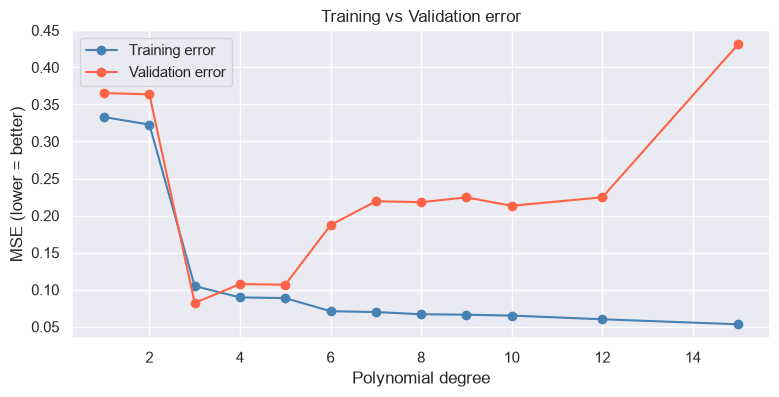

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(degrees, train_errors, 'o-', color='steelblue', label='Training error')
plt.plot(degrees, val_errors,   'o-', color='tomato',    label='Validation error')
plt.xlabel('Polynomial degree')
plt.ylabel('MSE (lower = better)')
plt.title('Training vs Validation error')
plt.legend()
plt.show()